In [15]:
from pathlib import Path
from dataclasses import dataclass
from collections import Counter
import editdistance
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

### This notebook computes the confidence intervals stratified per peptide edit distance to the training set using a nested bootstrap procedure. It should be run once for each model of the benchmark changing the *model* variable ('atm_tcr', 'rf', 'tulip' and 'xgb').

In [ ]:
np.random.seed(42)
## Bins for TCR counts. In our final output, bins will correspond to the **intervals**
## between the bin edges, e.g. [0,1) for bin 0, [1,20) for bin 1, etc. 
## Note: np.array([0,100000000]) bins effectively turn off binning over TCR count.
## **Only** counts for TCRs in the positive examples for each peptide will be used to assign the bins. 
## This is different from WEIGHT_PER_PEPTIDE_APPLIED_AFTER that counts all examples per peptide. Since
## our splits are 1:1 positive:negative, WEIGHT_PER_PEPTIDE_APPLIED_AFTER=40 corresponds to 20 positive 
## examples per peptide in the TCR binning.
BINS_TCR = np.array([0,21,101,100000000]) #np.array([0,100000000]) 
## Use the test TCR count to assign TCR count bins instead of train TCR counts for stratified ROC-AUC calculation.
DO_USE_TEST_TCR_COUNT = False
# Subsample test to have no more than that number of test cases (different TCRs) per each test peptide
N_TCR_PER_PEP_TEST=np.inf
## Resampling method for the bootstrap iterations.
## "naive" - sample rows with replacement from the full dataset.
## "pigeonhole" - independently sample TCRs and peptides as rows and columns of a sparse observation matrix,
## then take elements at the intersection of the sampled rows and columns. This implements
## Owen 2007 https://doi.org/10.1214/07-AOAS122 that accounts for clustering in both factors which resulted in
## the observed pairs. Note that this estimation can be "conservative" (give wider CIs),
## especially on very unbalanced datasets (in terms of TCR counts per peptide or vice versa).
## "within_peptide" - Resample test examples within each peptide to account for clustering of observations within peptides
## in terms of prediction difficulty - supported by observed association between performance and test TCR
## count per peptide.
RESAMPLING_METHOD = "within_peptide" # "naive", "pigeonhole" or "within_peptide"
## Inversely weight ROC-AUC by the number of examples per peptide.
## Scikit-learn function does the following when weights are supplied:
## https://github.com/scikit-learn/scikit-learn/blob/c5497b7f7eacfaff061cf68e09bcd48aa93d4d6b/sklearn/metrics/_ranking.py#L826
## tps = stable_cumsum(y_true * weight)[threshold_idxs]
## fps = stable_cumsum((1 - y_true) * weight)[threshold_idxs]
DO_WEIGHT_PER_PEPTIDE = True
## Only apply the weight per peptide if the number of examples per peptide is more than this value. E.g. if
## set to 40, then peptides with more than 40 examples will be weighted by 40 / N_examples_per_peptide.
# In Tulip split, there are <=20 positive examples => <40 total examples per peptide (36 is the actual observed max)
WEIGHT_PER_PEPTIDE_APPLIED_AFTER = 20 
## Exclude test TCRs found in the training set
DO_EXCLUDE_TEST_TCRS_FOUND_IN_TRAIN = True
## Count of bootstrap iterations inside each fold
## Do not make this <200 even though we are only picking one inner replicate per outer bootstrap.
## This is because we need variability of inner replicates across outer bootstrap iterations.
## Note that this number affects the compute time the most - the total time is O(N_BOOTS_INNER) + O(N_BOOTS_OUTER),
## not O(N_BOOTS_INNER * N_BOOTS_OUTER), and the auroc is estimated during the inner bootstrap iterations.
## This is the total number of inner bootstraps, which is the sum of all inner bootstraps across all folds.
N_BOOTS_INNER = 1000
## Count of bootstrap iterations when combining folds
N_BOOTS_OUTER = 5000
# Confidence interval level.
CI_ALPHA = 0.9
# Number of parallel jobs for bootstrap (-1 uses all available cores)
N_JOBS = -1

# Names of the models to process
#models = ['atm_tcr', 'rf', 'tulip', 'xgb', 'tcr-h']
models = ['atm_tcr','tulip','tcr-h']
# Names of the constructed dataset variants, should match a subdirectory in the results_model folder.
#dataset_names = ['tulip_split','cv_split']
dataset_names = ['cv_split','tulip_split']


In [17]:
@dataclass
class BootstrapConfig:
    """Configuration for bootstrap analysis."""
    model: str
    dataset_name: str
    
    def __post_init__(self):
        # Set number of folds based on dataset
        if self.dataset_name == "cv_split":
            self.n_folds = 5
        elif self.dataset_name == "tulip_split":
            self.n_folds = 1
        else:
            raise ValueError(f"Unknown dataset_name: {self.dataset_name}")
        
        # Set paths
        self.folder_results = Path(f"results_model/{self.dataset_name}/{self.model}/")
        self.ref_csv_path = f"dataset/{self.dataset_name}/" + "models_benchmark_dataset_{}.csv"
        self.output_path = Path(f"results_bootstrap/results_bootstrap_{self.dataset_name}_{self.model}.csv")


In [18]:
def roc_auc(y_true: np.ndarray, y_score: np.ndarray, sample_weight: np.ndarray | None = None, nan_on_failure: bool = True) -> float:
    """Compute ROC-AUC using sklearn integration.
    
    Args:
        y_true (np.ndarray): True labels.
        y_score (np.ndarray): Predicted scores.
        method (str): Method to use, either skt (scikit-learn) or ustat. Default skt.
        sample_weight (np.ndarray | None): Sample weights, if any to pass to skit-learn function.
        nan_on_failure (bool): If True, return NaN if ROC-AUC cannot be computed (e.g., only one class present)
    
    Returns:
        auroc (float): ROC-AUC using U-statistics.     
    """
    if not len(np.unique(y_true))>1:
            if nan_on_failure:
                return np.nan
            else:
                raise AssertionError("Only one class present in y_true. ROC-AUC is not defined in that case.")
    return roc_auc_score(y_true, y_score, sample_weight=sample_weight)

In [19]:
def bin_auroc(df_test: pd.DataFrame, df_train: pd.DataFrame) -> pd.DataFrame:
    """Bin ROC-AUC per peptide edit distance and TCR count bin.
    
    Peptide edit distance is evaluated with the closest peptide to the training set.
    TCR count corresponds to the number of TCRs in the training set associated to the closest train peptide.
    
    Args:
        df_test (pd.DataFrame): Test dataframe containing peptide, labels and scores.
        df_train (pd.DataFrame): Train dataframe containing peptide, CDR3b sequences, labels and scores.
        
    Returns:
        df_auroc (pd.DataFrame): DataFrame with ROC-AUC per bin (peptide edit distance, TCR count)   
    """
    df_train_cnt = df_train.groupby("peptide_train").agg(tcr_count=("y_true","sum")).reset_index()

    # Perform cross-join and compute all edit distances test-train peptides.
    df_test_pep = df_test[["peptide"]].drop_duplicates()
    df_train_cnt["key"] = 1
    df_test_pep["key"] = 1
    df_pep_dist = pd.merge(df_train_cnt, df_test_pep, on='key').drop('key', axis=1)
    df_pep_dist["dist"] = df_pep_dist.apply(lambda row: editdistance.eval(row["peptide"],row["peptide_train"]),axis=1)

    # Only keep rows with the minimum values (maybe many instances).
    min_dist = df_pep_dist.groupby('peptide')['dist'].transform('min')
    df_pep_dist = df_pep_dist[df_pep_dist['dist'] == min_dist]

    # Count TCR examples per test peptide per distance in this fold and assign count to TCR count bin.
    df_pep_dist_sum = df_pep_dist.groupby(["peptide","dist"])["tcr_count"].sum().reset_index()
    df_pep_dist_sum["tcr_bin"] = np.digitize(df_pep_dist_sum["tcr_count"],BINS_TCR)

    # Join distance and tcr count bins with test examples dataframe for each peptide.
    df_pep_bins = pd.merge(df_pep_dist_sum[["peptide","dist","tcr_bin"]], 
                           df_test[["peptide","y_true","y_score"]], on='peptide')

    # Group by distance and TCR bins and compute ROCAUC over all examples in each bin.
    # We store count of all observations to later find weighted auroc average.
    # We store count of unique peptides with positive examples to later mask histogram.
    # Bins with low peptide counts and to show the count on the plot.
    df_auroc = df_pep_bins.groupby(['dist','tcr_bin']).\
    apply(lambda rows: pd.Series({'rocauc': roc_auc(rows['y_true'], rows['y_score']),
                                  'obs_cnt': len(rows['y_true']),
                                 'pep_cnt': len(rows[rows['y_true']>0]['peptide'].unique())}),
                                 include_groups=False).\
    reset_index()
    return df_auroc

In [20]:
def _bootstrap_iteration(i_boot, df_pep_bins, pep_groups, pep_list, tcr_list,
                         resampling_method="naive", weighted_per_peptide=False, 
                         weight_per_peptide_applied_after=40,
                         use_test_tcr_count=False,
                         random_state=None):
    """Single bootstrap iteration function for parallel execution."""
    np.random.seed(random_state)
    
    if i_boot == 0:                        # original (non-resampled) sample
        df_pep_bins_boot = df_pep_bins
    else:
        if resampling_method == "within_peptide":
            # ---------- stage-1: resample peptides ------------------------
            ## Sample each peptide once (w/o replacement) if weighted_per_peptide is True to mitigate
            ## iflation of variance from weights computed on the resampled replicates. Without replacement for peptides,
            ## we are estimating variance for a future experiment that samples new TCRs for the same peptides.
            sampled_peps = np.random.choice(pep_list, size=len(pep_list), replace=False if weighted_per_peptide else True)

            # ---------- stage-2: resample rows inside each peptide --------
            rows = [
                pep_groups[pep].sample(n=len(pep_groups[pep]), replace=True)
                for pep in sampled_peps
            ]
            df_pep_bins_boot = pd.concat(rows, ignore_index=True)
        elif resampling_method == "pigeonhole":
            ## Implements Owen, Art B. ‘The Pigeonhole Bootstrap’. The Annals of Applied Statistics, 
            ## vol. 1, no. 2, Dec. 2007. DOI.org (Crossref), https://doi.org/10.1214/07-AOAS122
            # Stage-1a  —  resample peptides
            row_vec = np.random.choice(pep_list, size=len(pep_list), replace=True)
            k_row   = Counter(row_vec)            # multiplicity for each peptide
            # Stage-1b  —  resample TCRs
            col_vec = np.random.choice(tcr_list, size=len(tcr_list), replace=True)
            k_col   = Counter(col_vec)            # multiplicity for each TCR
            # ------ Stage-2  intersection with multiplicity -----------------------
            mult = (
                df_pep_bins["peptide"].map(k_row).fillna(0).to_numpy() *
                df_pep_bins["cdr3b"].map(k_col).fillna(0).to_numpy()
            )
            mask = mult > 0                       # row ∧ column intersection
            df_pep_bins_boot = df_pep_bins.loc[df_pep_bins.index[mask].repeat(mult[mask])].reset_index(drop=True)
        elif resampling_method == "naive":
            ## Naive resampling - sample rows with replacement from the full dataset.
            df_pep_bins_boot = df_pep_bins.sample(n=len(df_pep_bins), replace=True)
        else:
            raise ValueError(f"Unknown resampling method: {resampling_method}")

        # Recompute tcr_bin if using test TCR count for binning because the TCR counts may change in resampling.
        if use_test_tcr_count:
            len_inp = len(df_pep_bins_boot)
            df_test_tcr_cnt_boot = df_pep_bins_boot.groupby("peptide").agg(tcr_count=("y_true","sum")).reset_index()
            df_test_tcr_cnt_boot["tcr_bin"] = np.digitize(df_test_tcr_cnt_boot["tcr_count"], BINS_TCR)
            df_pep_bins_boot = df_pep_bins_boot.drop('tcr_bin', axis=1)
            df_pep_bins_boot = pd.merge(df_pep_bins_boot, df_test_tcr_cnt_boot[["peptide", "tcr_bin"]], on="peptide")
            assert len(df_pep_bins_boot) == len_inp, "Expected 1:1 join with test TCR count bins"

    # ---------- compute AUC in exactly the same way as before ---------        
    # Group by distance and TCR bins and compute ROCAUC over all examples in each bin.
    # We store count of all observations to later find weighted auroc average.
    # We store count of unique peptides with positive examples to later mask histogram.
    # bins with low peptide counts and to show the count on the plot
    
    def _compute_auroc(rows):
        if weighted_per_peptide:
            # Compute count of examples per peptide to use as sample weights
            pep_counts = rows.groupby("peptide")["y_true"].transform("size")
            sample_weights = np.minimum(weight_per_peptide_applied_after, pep_counts) / pep_counts
            rocauc = roc_auc(rows['y_true'], rows['y_score'], sample_weight=sample_weights)
        else:
            rocauc = roc_auc(rows['y_true'], rows['y_score'])
        
        return pd.Series({'rocauc': rocauc,
                         'obs_cnt': len(rows['y_true']),
                         'pep_cnt': len(rows[rows['y_true']>0]['peptide'].unique())})
    
    df_auroc = df_pep_bins_boot.groupby(['dist','tcr_bin']).\
    apply(_compute_auroc, include_groups=False).\
    reset_index()
    return df_auroc

def bin_auroc_boot_iter(df_test: pd.DataFrame, df_train: pd.DataFrame, n_boots: int = 0, 
                        resampling_method: str = "within_peptide", weighted_per_peptide: bool = False,
                        weight_per_peptide_applied_after: int = 40, use_test_tcr_count: bool = False) -> pd.DataFrame:
    """
    
    Args:
        df_test (pd.DataFrame): Test dataframe containing peptide, labels and scores.
        df_train (pd.DataFrame): Train dataframe containing peptide, CDR3b sequences, labels and scores.
        n_boots (int): Number of bootstrap iterations. Default 0.
        resampling_method (str): Resampling method to use. Default "within_peptide".
        weighted_per_peptide (bool): If True, compute ROC-AUC reversely weighted by the number of examples per peptide.
                                    Default False.
        weight_per_peptide_applied_after (int): If weighted_per_peptide is True, use this value to cap the weight
                                                applied to peptides with more than this number of examples.
                                                Default 40.
        use_test_tcr_count (bool): If True, use count of test TCRs per test peptide for binning instead of 
                                  training TCR counts. Default False.
    
    Returns:
        df_auroc (pd.DataFrame): DataFrame with ROC-AUC per bin (peptide edit distance, TCR count)       
    """
    print(f"Max count of examples per peptide in df_test: {df_test.groupby('peptide').size().max()}")

    df_train_cnt = df_train.groupby("peptide_train").agg(tcr_count=("y_true","sum")).reset_index()

    # Perform cross-join and compute all edit distances test-train peptides.
    df_test_pep = df_test[["peptide"]].drop_duplicates()
    df_train_cnt["key"] = 1
    df_test_pep["key"] = 1
    df_pep_dist = pd.merge(df_train_cnt, df_test_pep, on='key').drop('key', axis=1)
    df_pep_dist["dist"] = df_pep_dist.apply(lambda row: editdistance.eval(row["peptide"],row["peptide_train"]),axis=1)

    # Only keep rows with the minimum values (maybe many instances).
    min_dist = df_pep_dist.groupby('peptide')['dist'].transform('min')
    df_pep_dist = df_pep_dist[df_pep_dist['dist'] == min_dist]

    if use_test_tcr_count:
        # Use count of test TCRs per test peptide for binning. Here, this is done only to have a uniform
        # df_pep_dist_sum structure with the default choice of using train TCR counts. When test TCR counts are used,
        # the tcr_bin will be recomputed for each bootstrapped replica.
        df_test_tcr_cnt = df_test.groupby("peptide").agg(tcr_count=("y_true","sum")).reset_index()
        df_pep_dist_sum = df_pep_dist.groupby(["peptide","dist"]).first().reset_index()[["peptide","dist"]]
        df_pep_dist_sum = pd.merge(df_pep_dist_sum, df_test_tcr_cnt, on="peptide")
    else:
        # Count the nearest train TCR examples per test peptide per distance in this fold and assign count to TCR count bin.
        df_pep_dist_sum = df_pep_dist.groupby(["peptide","dist"])["tcr_count"].sum().reset_index()
    
    df_pep_dist_sum["tcr_bin"] = np.digitize(df_pep_dist_sum["tcr_count"],BINS_TCR)

    # Join distance and tcr count bins with test examples dataframe for each peptide.
    df_pep_bins = pd.merge(df_pep_dist_sum[["peptide","dist","tcr_bin"]], 
                           df_test[["peptide","y_true","y_score","cdr3b"]], on='peptide')

    assert len(df_pep_bins) == len(df_test), "Expected a single distance bin per each test peptide"
    
    # Prepare data for parallel execution
    pep_groups = {pep: grp for pep, grp in df_pep_bins.groupby("peptide")}
    pep_list   = list(pep_groups.keys())
    tcr_list = df_pep_bins["cdr3b"].unique()
    
    # Generate random states for reproducible parallel execution
    random_states = np.random.randint(0, 2**31, size=n_boots + 1)
    
    # Run bootstrap iterations in parallel
    results = Parallel(n_jobs=N_JOBS)(
        delayed(_bootstrap_iteration)(
            i_boot, df_pep_bins, pep_groups, pep_list, tcr_list, 
            resampling_method=resampling_method, 
            weighted_per_peptide=weighted_per_peptide, 
            weight_per_peptide_applied_after=weight_per_peptide_applied_after, 
            use_test_tcr_count=use_test_tcr_count,
            random_state=random_states[i_boot]
        ) for i_boot in range(n_boots + 1)
    )
    
    # Yield results in the same order as the original implementation
    for df_auroc in results:
        yield df_auroc

In [21]:
def auroc_over_folds(df_auroc_folds: pd.DataFrame) -> pd.DataFrame:
    """Aggregate ROC-AUC over the folds.
    
    Aggregate over all folds. ROCAUC is computed as an average weighted by counts of all observations in
    each fold (both positive and negative since they all contribute to ROC).
    
    Args:
        df_auroc_folds (pd.DataFrame): ROC-AUC and counts stratified per fold and bin.
    
    Returns:
        df_auroc (pd.DataFrame): ROC-AUC and counts aggregated over folds.    
    """
    def _aggr_rows(rows: pd.DataFrame) -> pd.Series:
        """Aggregation function per bin using a weighted average for the roc-auc and the sum for the counts.
        
        Args:
            rows (pd.DataFrame): Rows of the dataframe on which to aggregate.
        
        Returns:
            (pd.Series): Aggregated rows.        
        """
        rows = rows.dropna(subset=['rocauc'])
        return pd.Series({'rocauc': (rows['rocauc']*rows['obs_cnt']).sum()/rows['obs_cnt'].sum(),
                                  'obs_cnt': rows['obs_cnt'].sum(),
                                 'pep_cnt': rows['pep_cnt'].sum()})        
    df_auroc = df_auroc_folds.groupby(['dist','tcr_bin']).\
    apply(_aggr_rows,include_groups=False).\
    reset_index()
    return df_auroc

In [22]:
def boot_fold_boots(n_folds: int, n_boots_inner: int, n_boots_outer: int) -> pd.DataFrame:
    """Generate dataframe with outer bootstrap indices.

    The idea is to randomly combine bootsrapped samples within each fold, and repeat generation
    of these combined tuples `n_boots_outer` times. Note that we need fewer inner bootstraps with
    more n_folds because of this random combination of bootstraps across folds.
    Return value is a DataFrame with the following fields:
    `i_boot_inner` - for each fold, we select (with replacement) ONLY ONE bootstrap index that references 
    the internal fold-level bootstraps.
    `i_fold` iterates over folds
    `i_boot_outer` iterates of outer bootstrap loops
    The set with `i_boot_outer==0` is a special case: it contains `i_boot_innner=0` for every fold
    under a contract that `i_boot_inner=0` corresponds to non-bootsrapped original sample, and
    valid `i_boot_inner` runs from `0` to `n_boots_inner` inclusive. `i_boot_inner=0` will be only
    present in `i_boot_outer==0` set.
    Thus, `i_boot_outer` runs from `0` to `n_boots_outer` inclusive.
    
    Args:
        n_folds (int): Number of folds.
        n_boots_inner (int): Number of inner bootstraps.
        n_boots_outer (int): Number of outer bootstraps.
    
    Returns:
        boots (pd.DataFrame): DataFrame with outer bootstrap indices.
    """
    boots = []
    boots.append(pd.DataFrame({'i_fold':np.arange(1,n_folds+1,dtype=np.int_),
                               'i_boot_outer':np.int_(0),
                               'i_boot_inner':np.zeros(n_folds,dtype=np.int_)}))    
    for i_boot_outer in range(1,n_boots_outer+1):
        boots.append(pd.DataFrame({'i_fold':np.arange(1,n_folds+1,dtype=np.int_),
                                  'i_boot_outer':np.int_(i_boot_outer),
                                  'i_boot_inner':np.random.choice(range(1,n_boots_inner+1), size=n_folds, replace=True)}))
    boots = pd.concat(boots)
    return boots

In [23]:
def auroc_ci_from_boots(df_auroc_boot: pd.DataFrame, ci_alpha : float = 0.9) -> pd.DataFrame:
    """Aggregates ROC-AUC confidence intervals per bin.
    
    Args:
        df_auroc_boot (pd.DataFrame): DataFrame with ROC-AUC per bin for each bootstrap sample.
        ci_alpha (float): Confidence interval level. Default 0.9
    
    Returns:
        df_auroc (pd.DataFrame): DataFrame with ROC-AUC CI per bin computed over the bootstrap samples.
    """
    def _ci_metrics(rows: pd.DataFrame, ci_alpha: float = ci_alpha) -> pd.Series:
        ci_auc = np.quantile(rows['rocauc'], [0.5*(1-CI_ALPHA), 0.5*(1+CI_ALPHA)])
        return pd.Series({'rocauc_ci_low': ci_auc[0],
                          'rocauc_ci_high': ci_auc[1]})
    df_auroc = df_auroc_boot.groupby(['dist','tcr_bin']).\
    apply(_ci_metrics,include_groups=False).\
    reset_index()
    return df_auroc


### Run bootstrap using provided paths

In [24]:
def bootstrap_auroc_over_folds(n_folds, n_boots_inner_per_fold, folder_results, ref_csv_path):
    """Run bootstrap analysis over the folds"""
    pep_test_cnt_check = 0
    auroc_fold_check = []
    obs_cnt_check = []
    df_auroc_folds = []
    for fold in range(1, n_folds+1):
        csv_path = folder_results / f"fold_{fold}.csv"
        df_test = pd.read_csv(csv_path)
        ref_df = pd.read_csv(ref_csv_path.format(fold))
        
        # Train contains all non-test peptides.
        df_train = ref_df[~ref_df['peptide'].isin(df_test['peptide'].unique())]
        assert set(df_train['peptide']).intersection(set(df_test['peptide'])) == set()

        # Make sure correct labelling of columns.
        # We need cdr3b, y_true, y_score, peptide.
        df_train = df_train.rename(columns={
            "CDR3b": "cdr3b",
            "binder": "y_true",
            "peptide": "peptide_train"
        })
        
        # Filter out test examples where cdr3b is found in the training set
        if DO_EXCLUDE_TEST_TCRS_FOUND_IN_TRAIN:
            df_test = df_test[~df_test['cdr3b'].isin(df_train['cdr3b'])]

        df_test = df_test.sample(n=len(df_test),replace=False).\
        groupby(['peptide','y_true']).head(N_TCR_PER_PEP_TEST)

        print(f'Ratio of positives in test fold {fold}: {df_test["y_true"].mean()}; '
              f'count of positives: {df_test["y_true"].sum()}; '
              f'count of positive peptides: {df_test["peptide"].nunique()}')

        # Accumulate data for sanity checks.
        pep_test_cnt_check += len(df_test['peptide'].unique())
        auroc_fold_check.append(roc_auc(y_true=df_test['y_true'],y_score=df_test['y_score']))
        obs_cnt_check.append(df_test.shape[0])

        for i_boot, df_auroc_fold in enumerate(bin_auroc_boot_iter(df_test=df_test,
                                                                df_train=df_train, 
                                                                n_boots=n_boots_inner_per_fold,
                                                                resampling_method=RESAMPLING_METHOD,
                                                                weighted_per_peptide=DO_WEIGHT_PER_PEPTIDE,
                                                                weight_per_peptide_applied_after=WEIGHT_PER_PEPTIDE_APPLIED_AFTER,
                                                                use_test_tcr_count=DO_USE_TEST_TCR_COUNT)):
            df_auroc_fold['i_fold'] = fold
            df_auroc_fold['i_boot'] = i_boot
            df_auroc_folds.append(df_auroc_fold)

    auroc_fold_check = np.asarray(auroc_fold_check)
    obs_cnt_check = np.asarray(obs_cnt_check)

    df_auroc_folds = pd.concat(df_auroc_folds)
    # Shift tcr_bin to match expected offset of the plotting code.
    # Note that np.digitize will create bin=0 for values strictly less than the left edge of the first bin,
    # and it will be never present in the data because we do not have TCR counts < 1
    df_auroc_folds['tcr_bin'] -= 1

    n_auroc_na = df_auroc_folds['rocauc'].isna().sum()

    # Drop nan ROCAUC records in case we had cells with only one class.
    df_auroc_folds = df_auroc_folds[~df_auroc_folds['rocauc'].isna()]
    return df_auroc_folds, pep_test_cnt_check, auroc_fold_check, obs_cnt_check, n_auroc_na

In [25]:
def bootstrap_auroc_cis(n_folds, n_boots_inner_per_fold, df_auroc_folds, output_path):
    def _process_outer_bootstrap(i_boot_outer, fold_boots, df_auroc_folds):
        """Process a single outer bootstrap iteration."""
        fold_boot_i = fold_boots[fold_boots['i_boot_outer']==i_boot_outer]
        fold_boot_i = fold_boot_i.rename(columns={'i_boot_inner':'i_boot'})
        df_auroc_folds_boot_i = pd.merge(df_auroc_folds,
                                        fold_boot_i[['i_fold','i_boot']],on=['i_fold','i_boot'])
        # Compute AUROC aggregated over folds within bins.
        df_auroc_boot_i = auroc_over_folds(df_auroc_folds_boot_i)
        df_auroc_boot_i['i_boot'] = i_boot_outer
        return df_auroc_boot_i

    # Generate outer bootstrap indices.
    fold_boots = boot_fold_boots(n_folds, n_boots_inner = n_boots_inner_per_fold, n_boots_outer = N_BOOTS_OUTER)

    # Iterate over outer bootstrap samples in parallel.
    df_auroc_boot = Parallel(n_jobs=N_JOBS, verbose=0)(
        delayed(_process_outer_bootstrap)(i_boot_outer, fold_boots, df_auroc_folds)
        for i_boot_outer in range(N_BOOTS_OUTER+1)
    )

    df_auroc_boot = pd.concat(df_auroc_boot)
    # Aggregate results.
    df_auroc_ci = auroc_ci_from_boots(df_auroc_boot=df_auroc_boot[df_auroc_boot['i_boot']!=0],ci_alpha=CI_ALPHA)
    df_auroc = pd.merge(df_auroc_boot[df_auroc_boot['i_boot']==0].drop('i_boot',axis=1),
                        df_auroc_ci,on=['dist','tcr_bin'])
    # Save results.
    df_auroc.to_csv(output_path ,index=False)
    return df_auroc

In [26]:
def plot_auroc_heatmap(df_auroc, title="", figsize=(10, 8), save_path=None):
    """
    Create a 2D histogram plot showing ROC-AUC values with confidence intervals.
    
    Args:
        df_auroc (pd.DataFrame): DataFrame with columns 'dist', 'tcr_bin', 'rocauc', 
                                'rocauc_ci_low', 'rocauc_ci_high', 'pep_cnt'
        title (str): Title for the plot
        figsize (tuple): Figure size (width, height)
        save_path (str, optional): Path to save the figure
    
    Returns:
        fig, ax: matplotlib figure and axes objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create scatter plot with circle sizes based on sqrt(pep_cnt) for better visualization
    scatter = ax.scatter(df_auroc['dist'], df_auroc['tcr_bin'], 
                        s=np.sqrt(df_auroc['pep_cnt']) * 50,  # Scale factor for visibility
                        c=df_auroc['rocauc'], 
                        cmap='RdYlGn', 
                        vmin=0.3, vmax=0.8,  # Adjust based on your data range
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=0.5)
    
    # Add text annotations for each point
    for _, row in df_auroc.iterrows():
        x, y = row['dist'], row['tcr_bin']
        
        # Main ROC-AUC value (bold)
        ax.text(x, y + 0.25, f"{row['rocauc']:.2f}", 
                ha='center', va='center', 
                fontweight='bold', fontsize=12)
        
        # Confidence interval range
        ax.text(x, y + 0.1, f"{row['rocauc_ci_low']:.2f} - {row['rocauc_ci_high']:.2f}", 
                ha='center', va='center', 
                fontsize=9, color='black')
        
        # Peptide count
        ax.text(x, y - 0.15, f"{int(row['pep_cnt'])}", 
                ha='center', va='center', 
                fontsize=10)

        # Observation count
        ax.text(x, y - 0.25, f"{int(row['obs_cnt'])}", 
                ha='center', va='center', 
                fontsize=10)        
    
    # Customize the plot
    ax.set_xlabel('Edit distance to nearest training peptide', fontsize=12)
    ax.set_ylabel('Count of TCRs (positive)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Set axis limits and ticks
    ax.set_xlim(df_auroc['dist'].min() - 0.5, df_auroc['dist'].max() + 0.5)
    ax.set_ylim(df_auroc['tcr_bin'].min() - 0.5, df_auroc['tcr_bin'].max() + 0.5)
    
    # Set integer ticks
    ax.set_xticks(sorted(df_auroc['dist'].unique()))
    ax.set_yticks(sorted(df_auroc['tcr_bin'].unique()))
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('ROC-AUC', rotation=270, labelpad=15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


Model: atm_tcr, Dataset: cv_split
Number of bootstrap iterations: 1000 (inner), 5000 (outer)
Number of inner bootstrap iterations per fold: 200
Ratio of positives in test fold 1: 0.5225187522132441; count of positives: 32462; count of positive peptides: 302
Max count of examples per peptide in df_test: 17092
Ratio of positives in test fold 2: 0.5361201755373016; count of positives: 19058; count of positive peptides: 277
Max count of examples per peptide in df_test: 13263
Ratio of positives in test fold 3: 0.5069042427887628; count of positives: 20227; count of positive peptides: 272
Max count of examples per peptide in df_test: 15374
Ratio of positives in test fold 4: 0.520799512987013; count of positives: 30798; count of positive peptides: 280
Max count of examples per peptide in df_test: 26007
Ratio of positives in test fold 5: 0.49982917663136317; count of positives: 20482; count of positive peptides: 273
Max count of examples per peptide in df_test: 12901
AUROC could not be compute

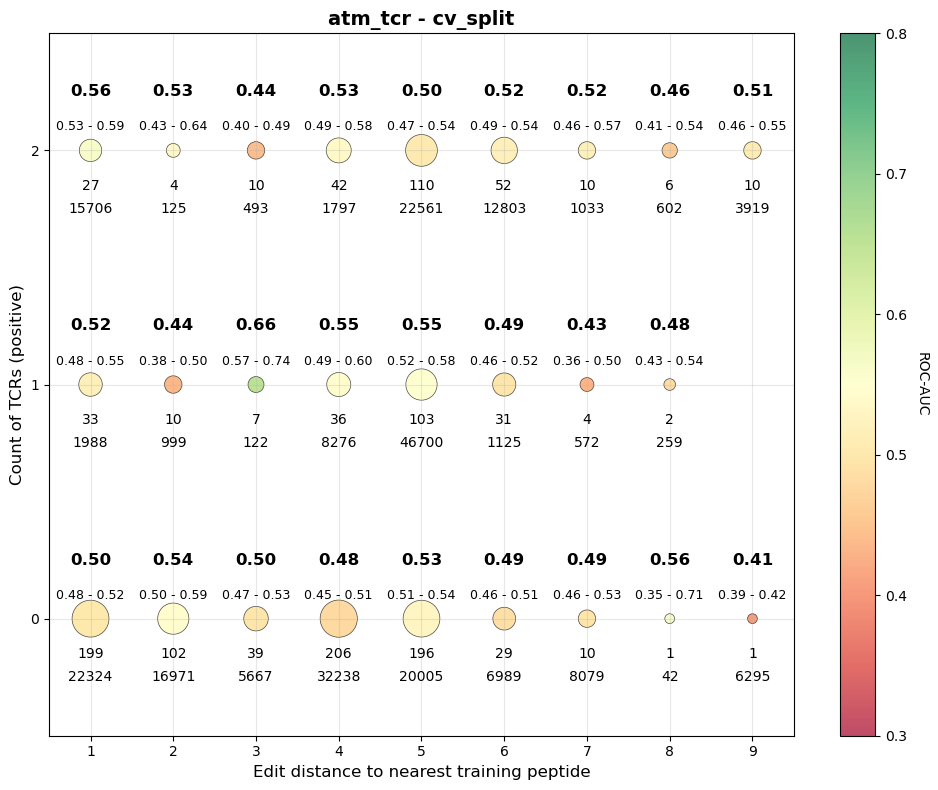

Model: tcr-h, Dataset: cv_split
Number of bootstrap iterations: 1000 (inner), 5000 (outer)
Number of inner bootstrap iterations per fold: 200
Ratio of positives in test fold 1: 0.5225103417193813; count of positives: 32462.0; count of positive peptides: 302
Max count of examples per peptide in df_test: 17092
Ratio of positives in test fold 2: 0.5361050943767757; count of positives: 19058.0; count of positive peptides: 277
Max count of examples per peptide in df_test: 13263
Ratio of positives in test fold 3: 0.5068668237181093; count of positives: 20225.0; count of positive peptides: 272
Max count of examples per peptide in df_test: 15375
Ratio of positives in test fold 4: 0.5207907063259888; count of positives: 30798.0; count of positive peptides: 280
Max count of examples per peptide in df_test: 26007
Ratio of positives in test fold 5: 0.4998169704956439; count of positives: 20481.0; count of positive peptides: 273
Max count of examples per peptide in df_test: 12901
AUROC could not be

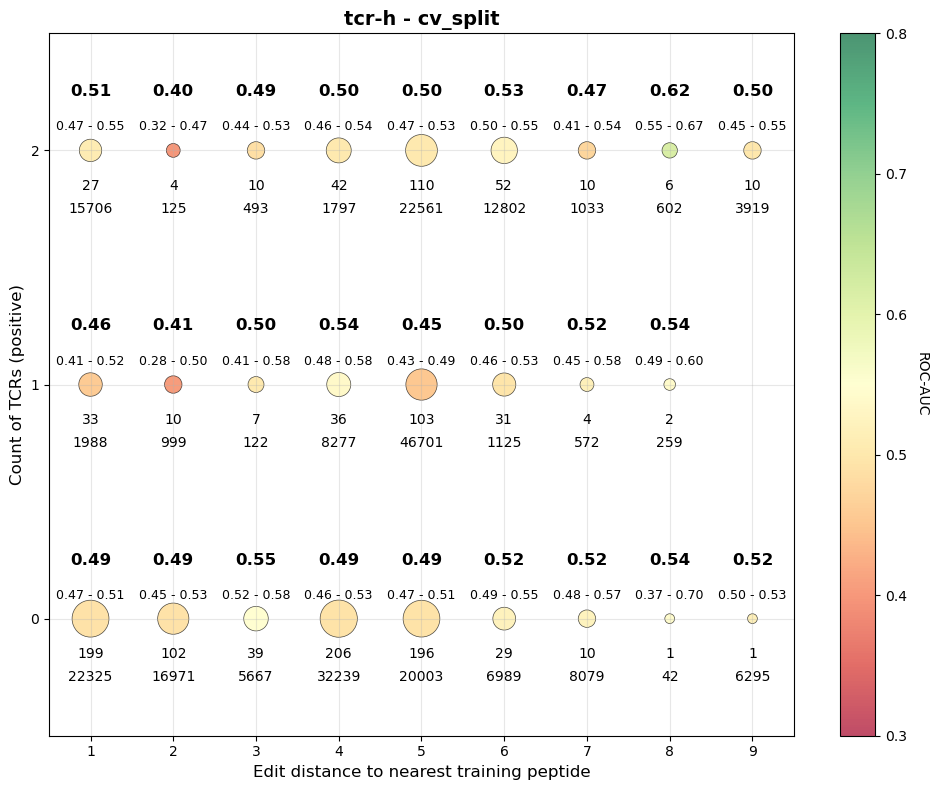

In [27]:
for model in models:
    for dataset_name in dataset_names:
        # Create configuration instance
        config = BootstrapConfig(model=model, dataset_name=dataset_name)
        
        print(f"Model: {model}, Dataset: {dataset_name}")
        print(f"Number of bootstrap iterations: {N_BOOTS_INNER} (inner), {N_BOOTS_OUTER} (outer)")
        
        n_folds = config.n_folds
        folder_results = config.folder_results
        ref_csv_path = config.ref_csv_path
        output_path = config.output_path
        n_boots_inner_per_fold = N_BOOTS_INNER // n_folds
        print(f"Number of inner bootstrap iterations per fold: {n_boots_inner_per_fold}")

        if not folder_results.exists():
            print(f"Folder with model results '{folder_results}' does not exist. Skipping...")
            continue

        # Run bootstrap over the folds
        df_auroc_folds, pep_test_cnt_check, auroc_fold_check, obs_cnt_check, n_auroc_na = bootstrap_auroc_over_folds(
            n_folds, n_boots_inner_per_fold, folder_results, ref_csv_path)

        print(f"AUROC could not be computed for {n_auroc_na} inner bootstrap replicas.")

        # Run bootstrap confidence intervals
        df_auroc = bootstrap_auroc_cis(n_folds, n_boots_inner_per_fold, df_auroc_folds, output_path)
        print(df_auroc)
        # Example usage after running the bootstrap analysis:
        fig, ax = plot_auroc_heatmap(df_auroc, title=f"{model} - {dataset_name}", save_path=output_path.with_suffix('.png'))
        plt.show()


In [28]:
# Check that bootstrap selects the expected number of units: for pigeonhole resampling, we expect
# pep_count (number of unique peptides) in each replica to be ~63% of all unique peptides in a fold 
# (~pep_count/n_folds from df_auroc),
# but in this table it will be slightly lower because we dropped rows with NaN ROC-AUC before
# we aggregated into this table
df_auroc_folds.groupby('dist')[['obs_cnt','pep_cnt']].mean()

,obs_cnt,pep_cnt
dist,,
1,2667.933333,15.862355
2,1663.767155,9.532479
3,448.870956,3.718450
4,2820.866667,17.352570
5,5951.000000,25.033167
6,1394.400000,7.063018
7,925.026141,2.221483
8,129.000000,1.280739
9,2042.800000,2.151244
